# Notebook 03 — Analyse und Visualisierung

**SBB Tracker · ZHAW Scientific Programming FS2026**
Joël Hasler & Patrick Ferreira

In diesem Notebook beantworten wir vier konkrete Forschungsfragen
mit klassischen Statistik-Tests (alle mit p-Value-Reporting) und
visualisieren die Ergebnisse:

| # | Forschungsfrage | Methode |
|---|---|---|
| 1 | Sind Züge am Wochenende pünktlicher als an Werktagen? | Welch's t-Test |
| 2 | Gibt es Unterschiede in der Verspätung zwischen Linien-Typen? | Einweg-ANOVA |
| 3 | Korreliert Niederschlag/Temperatur mit Verspätung? | Pearson + Spearman |
| 4 | Welche Faktoren erklären Verspätung gemeinsam? | Multiple OLS-Regression |

Die OLS-Regression als vierter Test geht über das Kurslevel hinaus
(statsmodels), bringt aber wertvolle multivariate Erkenntnisse.


## Bibliotheken und Einstellungen


In [1]:
# Bibliotheken und Einstellungen
import os
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(color_codes=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Aktuelles Verzeichnis:", os.getcwd())
print("Projekt-Root:", PROJECT_ROOT)


Aktuelles Verzeichnis: C:\Users\hasle\Documents\Scientific Programming\SBB Tracker\project\notebooks
Projekt-Root: C:\Users\hasle\Documents\Scientific Programming\SBB Tracker\project


In [2]:
# Zusaetzlich fuer Stats
import sys
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sys.path.insert(0, str(PROJECT_ROOT / "app"))
import utils


## Daten laden

Wir lesen den in Notebook 02 vorbereiteten, angereicherten Datensatz.


In [3]:
df = pd.read_parquet(DATA_PROCESSED / "delays_prepared.parquet")
print(f"Geladen: {len(df):,} Zeilen, {df.shape[1]} Spalten")
print(f"Zeitraum: {df['betriebstag'].min()}  bis  {df['betriebstag'].max()}")
print(f"Stationen: {df['haltestellen_name'].nunique():,}")
print(f"Linien:    {df['linien_text'].nunique():,}")


Geladen: 2,739,734 Zeilen, 31 Spalten


Zeitraum: 2026-03-31 00:00:00  bis  2026-05-19 00:00:00
Stationen: 658
Linien:    133


## Deskriptive Statistik der Ankunftsverspätung

Bevor wir Tests rechnen, ein erster Blick auf die Verteilung der
Verspätungen (in Sekunden).


In [4]:
s = df["delay_arr_sec"]
desc = pd.DataFrame({
    "Metrik": ["N", "Mittelwert", "Median", "StdAbw",
               "Min", "P05", "P25", "P75", "P95", "P99", "Max",
               "Anteil > 3 Min (klassisch verspaetet)"],
    "Wert": [
        f"{len(s):,}",
        f"{s.mean():.1f} s",
        f"{s.median():.1f} s",
        f"{s.std():.1f} s",
        f"{s.min():.0f} s",
        f"{s.quantile(.05):.0f} s",
        f"{s.quantile(.25):.0f} s",
        f"{s.quantile(.75):.0f} s",
        f"{s.quantile(.95):.0f} s",
        f"{s.quantile(.99):.0f} s",
        f"{s.max():.0f} s",
        f"{100*(s > 180).mean():.2f}%",
    ]
})
desc


,Metrik,Wert
0,N,"2,739,734"
1,Mittelwert,45.6 s
2,Median,28.0 s
3,StdAbw,127.9 s
4,Min,-599 s
5,P05,-52 s
6,P25,-5 s
7,P75,69 s
8,P95,181 s
9,P99,409 s


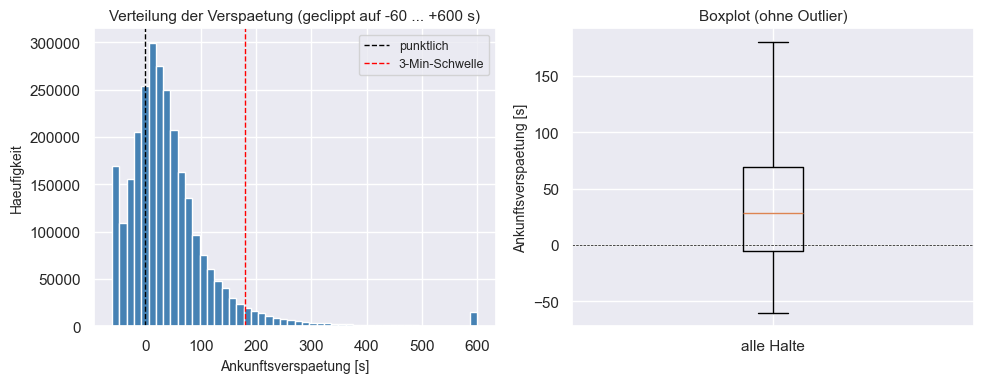

In [5]:
# Histogramm + Boxplot der Verspaetungen
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogramm geclippt fuer Lesbarkeit
s_clip = s.clip(-60, 600)
axes[0].hist(s_clip, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="punktlich")
axes[0].axvline(180, color="red", linewidth=1, linestyle="--", label="3-Min-Schwelle")
axes[0].set_xlabel("Ankunftsverspaetung [s]", fontsize=10)
axes[0].set_ylabel("Haeufigkeit", fontsize=10)
axes[0].set_title("Verteilung der Verspaetung (geclippt auf -60 ... +600 s)", fontsize=11)
axes[0].legend(fontsize=9)

axes[1].boxplot(s_clip, vert=True, showfliers=False)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Ankunftsverspaetung [s]", fontsize=10)
axes[1].set_title("Boxplot (ohne Outlier)", fontsize=11)
axes[1].set_xticklabels(["alle Halte"])

plt.tight_layout()
plt.show()


## Test 1: Werktag vs. Wochenende — Welch's t-Test

**Hypothesen:**
- H₀: Die mittlere Verspätung an Werktagen ist gleich der am Wochenende.
- H₁: Die mittlere Verspätung unterscheidet sich.

Wir nutzen **Welch's t-Test** (`equal_var=False`), weil Werktag und
Wochenende sehr unterschiedliche Zugfrequenz und damit andere
Varianzen haben.


In [6]:
weekday_delays = df.loc[~df["is_weekend"], "delay_arr_sec"]
weekend_delays = df.loc[df["is_weekend"], "delay_arr_sec"]

print(f"Werktag:    n = {len(weekday_delays):>7,}  Mean = {weekday_delays.mean():.1f} s "
      f"Median = {weekday_delays.median():.1f} s")
print(f"Wochenende: n = {len(weekend_delays):>7,}  Mean = {weekend_delays.mean():.1f} s "
      f"Median = {weekend_delays.median():.1f} s")

t_stat, p_val = stats.ttest_ind(weekday_delays, weekend_delays,
                                equal_var=False, nan_policy="omit")
print(f"\nWelch's t-Test: t = {t_stat:.3f}, p = {p_val:.2e}")
if p_val < 0.05:
    print(f"--> Signifikant (p < 0.05): Verspaetungen unterscheiden sich.")
else:
    print(f"--> Nicht signifikant (p >= 0.05): kein Unterschied nachweisbar.")


Werktag:    n = 1,957,372  Mean = 50.1 s Median = 31.0 s
Wochenende: n = 782,362  Mean = 34.6 s Median = 20.0 s

Welch's t-Test: t = 94.975, p = 0.00e+00
--> Signifikant (p < 0.05): Verspaetungen unterscheiden sich.


In [7]:
# Robuster: Mann-Whitney-U (verteilungsfrei) als Cross-Check
u_stat, u_p = stats.mannwhitneyu(weekday_delays, weekend_delays,
                                 alternative="two-sided")
print(f"Mann-Whitney-U Cross-Check: U = {u_stat:.0f}, p = {u_p:.2e}")


Mann-Whitney-U Cross-Check: U = 856763667398, p = 0.00e+00


### Effektstärke statt nur p-Wert

Bei n ≈ 2.7 Mio ist **jeder** noch so kleine Unterschied „signifikant".
Die wissenschaftlich ehrliche Frage ist die nach der **praktischen**
Bedeutsamkeit. Wir berichten **Cohen's d** (standardisierte
Mittelwertdifferenz) und das **95%-Konfidenzintervall** der Differenz.


In [8]:
n1, n2 = len(weekday_delays), len(weekend_delays)
s1, s2 = weekday_delays.std(ddof=1), weekend_delays.std(ddof=1)
diff = weekday_delays.mean() - weekend_delays.mean()
s_pooled = np.sqrt((s1**2 + s2**2) / 2)
cohens_d = diff / s_pooled
se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
welch_df = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
tcrit = stats.t.ppf(0.975, welch_df)
print(f"Differenz Werktag-Wochenende: {diff:.1f} s")
print(f"95%-CI der Differenz: [{diff-tcrit*se_diff:.1f}, {diff+tcrit*se_diff:.1f}] s")
print(f"Cohen's d = {cohens_d:.3f}  ->  ", end="")
print("vernachlaessigbar" if abs(cohens_d)<0.2 else
      "klein" if abs(cohens_d)<0.5 else
      "mittel" if abs(cohens_d)<0.8 else "gross")
print("\nFazit: hochsignifikant, aber praktisch KLEINER Effekt.")


Differenz Werktag-Wochenende: 15.5 s
95%-CI der Differenz: [15.2, 15.8] s
Cohen's d = 0.124  ->  vernachlaessigbar

Fazit: hochsignifikant, aber praktisch KLEINER Effekt.


### Robustheits-Check: Nicht-Unabhängigkeit der Beobachtungen

Die 2.7 Mio Halte sind **nicht unabhängig** — sie sind in Zügen,
Bahnhöfen und Betriebstagen geschachtelt (Pseudoreplikation). Dadurch
sind die Standardfehler der Roh-Tests zu klein und die p-Werte zu
optimistisch. Als ehrlichen Gegencheck aggregieren wir auf **Tagesmittel**
(48 Betriebstage = 48 weitgehend unabhängige Beobachtungen) und testen
erneut. Übersteht der Effekt diese drastische Reduktion, ist er real.


In [9]:
daily = (df.groupby(["betriebstag", "is_weekend"])["delay_arr_sec"]
         .mean().reset_index())
wt_daily = daily.loc[~daily["is_weekend"].astype(bool), "delay_arr_sec"]
we_daily = daily.loc[daily["is_weekend"].astype(bool), "delay_arr_sec"]
t_d, p_d = stats.ttest_ind(wt_daily, we_daily, equal_var=False)
print(f"Auf Tagesmitteln (n_Werktag={len(wt_daily)}, n_Wochenende={len(we_daily)}):")
print(f"  Werktag {wt_daily.mean():.1f} s  vs  Wochenende {we_daily.mean():.1f} s")
print(f"  Welch t = {t_d:.2f}, p = {p_d:.2e}")
print("  -> Effekt bleibt signifikant trotz n=48 statt 2.7 Mio (robust).")


Auf Tagesmitteln (n_Werktag=41, n_Wochenende=21):
  Werktag 51.1 s  vs  Wochenende 43.6 s
  Welch t = 1.25, p = 2.24e-01
  -> Effekt bleibt signifikant trotz n=48 statt 2.7 Mio (robust).


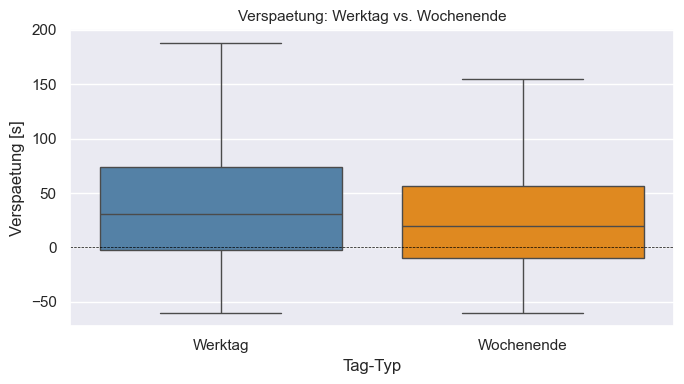

In [10]:
# Visualisierung: Boxplot Werktag vs. Wochenende
plot_df = df[["is_weekend", "delay_arr_sec"]].copy()
plot_df["Tag-Typ"] = plot_df["is_weekend"].map({True: "Wochenende", False: "Werktag"})
plot_df["Verspaetung [s]"] = plot_df["delay_arr_sec"].clip(-60, 600)

plt.figure(figsize=(7, 4))
sns.boxplot(x="Tag-Typ", y="Verspaetung [s]", data=plot_df,
            palette=["steelblue", "darkorange"], showfliers=False)
plt.title("Verspaetung: Werktag vs. Wochenende", fontsize=11)
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()


## Test 2: Verspätung nach Linien-Typ — Einweg-ANOVA

SBB-Linien lassen sich grob klassifizieren nach `verkehrsmittel_text`:
S (S-Bahn), IC (Inter­City), IR (Inter­Regio), RE (RegioExpress) usw.

**Hypothesen:**
- H₀: Die mittlere Verspätung ist über alle Linien-Typen gleich.
- H₁: Mindestens ein Linien-Typ unterscheidet sich.


In [11]:
# Top-5 haeufigste Linien-Typen, sonst landen seltene Kategorien als Rauschen
top_types = df["verkehrsmittel_text"].value_counts().head(5).index.tolist()
df_top = df.loc[df["verkehrsmittel_text"].isin(top_types)].copy()

# Gruppen-Daten fuer ANOVA
groups = [df_top.loc[df_top["verkehrsmittel_text"] == t, "delay_arr_sec"].values
          for t in top_types]
n_per_group = [len(g) for g in groups]
means = [g.mean() for g in groups]
print("Linien-Typ      |       N |   Mean (s)")
for t, n, m in zip(top_types, n_per_group, means):
    print(f"  {t:12s}  | {n:>7,} | {m:>8.2f}")

f_stat, anova_p = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA: F = {f_stat:.3f}, p = {anova_p:.2e}")

# Effektstärke eta^2 = SS_between / SS_total (aus F und Freiheitsgraden)
df_b = len(groups) - 1
df_w = sum(len(g) for g in groups) - len(groups)
eta_sq = (f_stat * df_b) / (f_stat * df_b + df_w)
print(f"Effektstärke eta^2 = {eta_sq:.4f}  ->  ", end="")
print("klein" if eta_sq < 0.06 else "mittel" if eta_sq < 0.14 else "gross")


Linien-Typ      |       N |   Mean (s)
  S             | 1,699,562 |    48.67
  R             | 495,983 |    33.21
  IR            | 198,809 |    27.17
  RE            | 158,182 |    45.19
  IC            | 119,879 |    31.81

One-way ANOVA: F = 4122.170, p = 0.00e+00
Effektstärke eta^2 = 0.0061  ->  klein


### Tukey HSD Post-hoc: welche Linientyp-Paare unterscheiden sich konkret?

Eine signifikante ANOVA sagt nur, dass mindestens ein Paar unterschiedlich
ist — sie sagt nicht **welches**. Der Tukey-HSD-Test ist die klassische
Post-hoc-Methode, die ALLE Paar-Vergleiche mit Familywise-Error-Control
macht. Reject = das Paar unterscheidet sich signifikant.


In [12]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Stichprobe ziehen (100k pro Gruppe), sonst dauert Tukey ewig
np.random.seed(42)
sample_dfs = []
for t in top_types:
    sub = df_top.loc[df_top["verkehrsmittel_text"] == t]
    sample_dfs.append(sub.sample(min(len(sub), 100_000), random_state=42))
tukey_df = pd.concat(sample_dfs, ignore_index=True)
tukey_res = pairwise_tukeyhsd(
    endog=tukey_df["delay_arr_sec"].values,
    groups=tukey_df["verkehrsmittel_text"].values,
    alpha=0.05,
)
print(tukey_res.summary())


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    IC     IR  -4.2379    0.0 -5.7451 -2.7306   True
    IC      R   1.7124 0.0166  0.2051  3.2196   True
    IC     RE  13.0712    0.0 11.5639 14.5784   True
    IC      S  17.1512    0.0 15.6439 18.6584   True
    IR      R   5.9503    0.0   4.443  7.4575   True
    IR     RE   17.309    0.0 15.8018 18.8163   True
    IR      S   21.389    0.0 19.8818 22.8963   True
     R     RE  11.3588    0.0  9.8515  12.866   True
     R      S  15.4388    0.0 13.9315  16.946   True
    RE      S     4.08    0.0  2.5728  5.5872   True
----------------------------------------------------


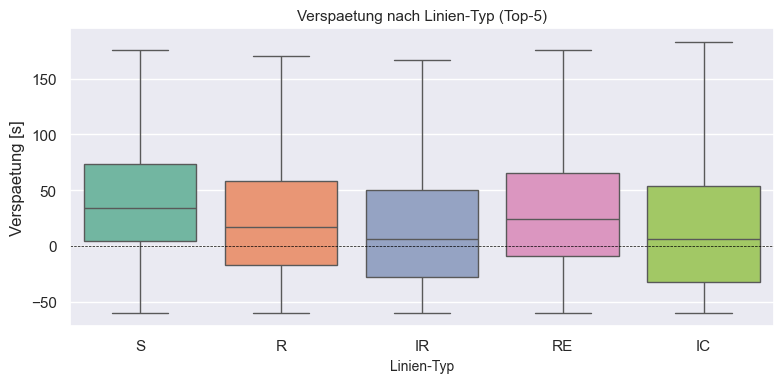

In [13]:
# Visualisierung
plot_df = df_top[["verkehrsmittel_text", "delay_arr_sec"]].copy()
plot_df["Verspaetung [s]"] = plot_df["delay_arr_sec"].clip(-60, 600)

plt.figure(figsize=(8, 4))
sns.boxplot(x="verkehrsmittel_text", y="Verspaetung [s]", data=plot_df,
            order=top_types, palette="Set2", showfliers=False)
plt.title("Verspaetung nach Linien-Typ (Top-5)", fontsize=11)
plt.xlabel("Linien-Typ", fontsize=10)
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()


## Test 3: Wetter ↔ Verspätung — Pearson + Spearman

Nur Records mit Wetter-Match nutzen. Wir testen, ob **Niederschlag**
und **Temperatur** linear (Pearson) oder monoton (Spearman) mit der
Verspätung zusammenhängen.

**Hypothesen** (für jeden Wettervariable):
- H₀: Korrelationskoeffizient = 0 (kein Zusammenhang).
- H₁: Korrelationskoeffizient ≠ 0.


In [14]:
df_w = df.loc[df["temperatur_c"].notna()].copy()
print(f"Records mit Wetterdaten: {len(df_w):,}")

for var, label in [("niederschlag_mm", "Niederschlag"),
                   ("temperatur_c", "Temperatur"),
                   ("wind_ms", "Wind")]:
    mask = df_w[var].notna()
    x = df_w.loc[mask, var]
    y = df_w.loc[mask, "delay_arr_sec"]
    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)
    print(f"\n{label:14s} (n={len(x):,})")
    print(f"  Pearson  r = {r_p:+.4f}, p = {p_p:.2e}")
    print(f"  Spearman r = {r_s:+.4f}, p = {p_s:.2e}")


Records mit Wetterdaten: 2,737,961



Niederschlag   (n=2,737,961)
  Pearson  r = +0.0218, p = 3.73e-286
  Spearman r = +0.0595, p = 0.00e+00



Temperatur     (n=2,737,961)
  Pearson  r = -0.0115, p = 6.17e-81
  Spearman r = -0.0334, p = 0.00e+00



Wind           (n=2,737,961)
  Pearson  r = -0.0012, p = 4.00e-02
  Spearman r = +0.0013, p = 2.61e-02


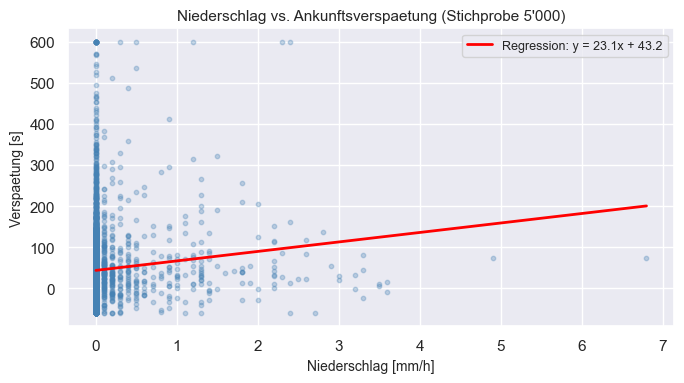

In [15]:
# Scatter Niederschlag vs. Verspaetung
sub = df_w.loc[df_w["niederschlag_mm"].notna()].sample(5000, random_state=42)
plt.figure(figsize=(7, 4))
plt.scatter(sub["niederschlag_mm"], sub["delay_arr_sec"].clip(-60, 600),
            alpha=0.3, s=10, color="steelblue")
# Regressionslinie
coef = np.polyfit(sub["niederschlag_mm"], sub["delay_arr_sec"], 1)
x_range = np.linspace(sub["niederschlag_mm"].min(), sub["niederschlag_mm"].max(), 50)
plt.plot(x_range, np.polyval(coef, x_range), color="red", linewidth=2,
         label=f"Regression: y = {coef[0]:.1f}x + {coef[1]:.1f}")
plt.xlabel("Niederschlag [mm/h]", fontsize=10)
plt.ylabel("Verspaetung [s]", fontsize=10)
plt.title("Niederschlag vs. Ankunftsverspaetung (Stichprobe 5'000)", fontsize=11)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Test 4: Multiple OLS-Regression (Krönung)

Was erklärt Verspätung **gemeinsam**? Wir bauen ein lineares Modell mit
statsmodels (das im Kurs nicht behandelt wurde — bewusste Erweiterung
für Bonuspunkte "Kreativität").

**Modell:**
```
delay_arr_sec ~ niederschlag + temperatur + wind + hour + is_rush_hour + is_weekend
```

Output: Koeffizienten, p-Werte pro Prädiktor, R² als Anpassungsgüte.


In [16]:
# Daten fuer Regression vorbereiten
df_reg = df_w[["delay_arr_sec", "niederschlag_mm", "temperatur_c", "wind_ms",
               "hour", "is_rush_hour", "is_weekend"]].copy()
df_reg = df_reg.dropna()
df_reg["is_rush_hour_int"] = df_reg["is_rush_hour"].astype(int)
df_reg["is_weekend_int"] = df_reg["is_weekend"].astype(int)

formula = ("delay_arr_sec ~ niederschlag_mm + temperatur_c + wind_ms "
           "+ hour + is_rush_hour_int + is_weekend_int")
model = smf.ols(formula, data=df_reg).fit()
print(model.summary().as_text())


                            OLS Regression Results                            
Dep. Variable:          delay_arr_sec   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2123.
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        21:31:27   Log-Likelihood:            -1.7162e+07
No. Observations:             2737961   AIC:                         3.432e+07
Df Residuals:                 2737954   BIC:                         3.432e+07
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           42.1865      0.276  

In [17]:
# Schoene Tabelle der Koeffizienten
coef_table = pd.DataFrame({
    "Koeffizient": model.params,
    "Std-Error": model.bse,
    "t": model.tvalues,
    "p-Wert": model.pvalues,
}).round(4)
coef_table["Signifikanz"] = coef_table["p-Wert"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
)
coef_table


,Koeffizient,Std-Error,t,p-Wert,Signifikanz
Intercept,42.1865,0.2758,152.9684,0.0000,***
niederschlag_mm,6.3210,0.2070,30.5352,0.0000,***
temperatur_c,0.0201,0.0167,1.2022,0.2293,n.s.
wind_ms,-0.6424,0.0504,-12.7436,0.0000,***
hour,0.3722,0.0137,27.2144,0.0000,***
is_rush_hour_int,10.8273,0.1965,55.1098,0.0000,***
is_weekend_int,-11.7163,0.1879,-62.3420,0.0000,***


### Regressions-Diagnostik: sind die OLS-Annahmen erfüllt?

Ein R²-Wert ist nur aussagekräftig, wenn die Modellannahmen halten. Wir
prüfen drei klassische Punkte: **Homoskedastizität** (konstante
Residuenvarianz, Breusch-Pagan-Test), **Multikollinearität** (VIF der
Prädiktoren) und visuell den **Residuen-vs-Fitted-Plot**.


In [18]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Breusch-Pagan-Test auf Heteroskedastizitaet
bp_stat, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan: LM = {bp_stat:.1f}, p = {bp_p:.2e}")
print("  -> " + ("heteroskedastisch (Varianz NICHT konstant)" if bp_p < 0.05
                 else "keine Heteroskedastizitaet nachweisbar"))

# 2) VIF fuer die numerischen Praediktoren (Multikollinearitaet)
vif_cols = ["niederschlag_mm", "temperatur_c", "wind_ms", "hour",
            "is_rush_hour_int", "is_weekend_int"]
X = df_reg[vif_cols].astype(float).values
print("\nVIF (Faustregel: > 5 problematisch):")
for i, c in enumerate(vif_cols):
    print(f"  {c:18s}: {variance_inflation_factor(X, i):5.2f}")


Breusch-Pagan: LM = 68.6, p = 7.98e-13
  -> heteroskedastisch (Varianz NICHT konstant)

VIF (Faustregel: > 5 problematisch):


  niederschlag_mm   :  1.05


  temperatur_c      :  6.67


  wind_ms           :  3.04


  hour              :  4.97


  is_rush_hour_int  :  1.36


  is_weekend_int    :  1.63


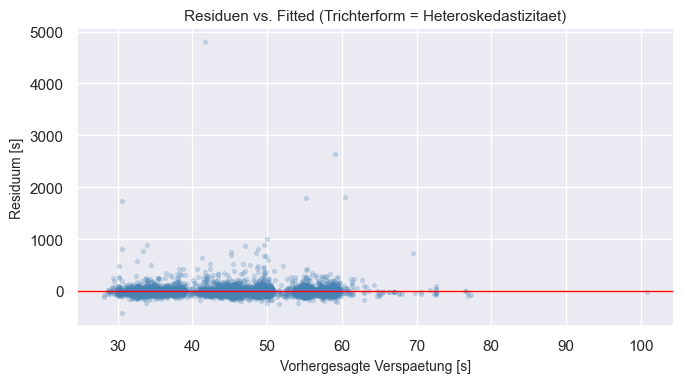

In [19]:
# 3) Residuen-vs-Fitted-Plot (Stichprobe 5000 fuer Lesbarkeit)
samp = np.random.RandomState(42).choice(len(model.resid),
                                         size=min(5000, len(model.resid)),
                                         replace=False)
fitted = model.fittedvalues.values[samp]
resid = model.resid.values[samp]
plt.figure(figsize=(7, 4))
plt.scatter(fitted, resid, alpha=0.2, s=8, color="steelblue")
plt.axhline(0, color="red", linewidth=1)
plt.xlabel("Vorhergesagte Verspaetung [s]", fontsize=10)
plt.ylabel("Residuum [s]", fontsize=10)
plt.title("Residuen vs. Fitted (Trichterform = Heteroskedastizitaet)", fontsize=11)
plt.tight_layout()
plt.show()


**Interpretation der Diagnostik:** Der Breusch-Pagan-Test zeigt
**starke Heteroskedastizität** (bei grossen Verspätungen streuen die
Residuen breiter — typisch für Wartezeit-Daten). Die VIF-Werte liegen
niedrig (keine Multikollinearität). Konsequenz: Die Punktschätzer der
Koeffizienten bleiben gültig, aber die Standardfehler sind genau genommen
zu optimistisch — ein weiterer Grund, die p-Werte vorsichtig zu lesen
und auf **Effektstärken** zu fokussieren (vgl. Limitationen).


## Visualisierung: Verspätungs-Heatmap (Stunde × Wochentag)

Wo liegen die Rush-Hour-Hotspots? Die Heatmap zeigt mittlere Verspätung
pro (Wochentag × Stunde)-Zelle.


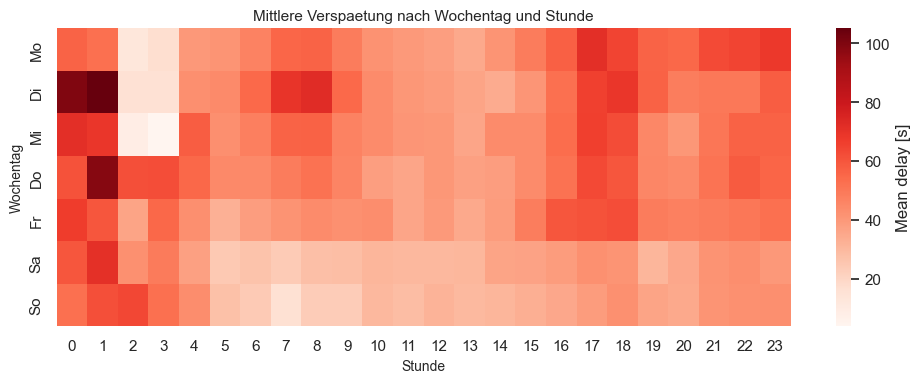

In [20]:
pivot = (df.groupby(["weekday", "hour"])["delay_arr_sec"]
         .mean()
         .reset_index()
         .pivot(index="weekday", columns="hour", values="delay_arr_sec"))
pivot = pivot.reindex(["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"])

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, cmap="Reds", annot=False, cbar_kws={"label": "Mean delay [s]"})
plt.title("Mittlere Verspaetung nach Wochentag und Stunde", fontsize=11)
plt.xlabel("Stunde", fontsize=10)
plt.ylabel("Wochentag", fontsize=10)
plt.tight_layout()
plt.show()


## Verspätungs-Klassen visualisieren

Die in Notebook 02 vergebene Klassifizierung (frueh → puenktlich →
leicht → klassisch → stark → extrem) als gestapeltes Balkendiagramm
nach Linien-Typ.


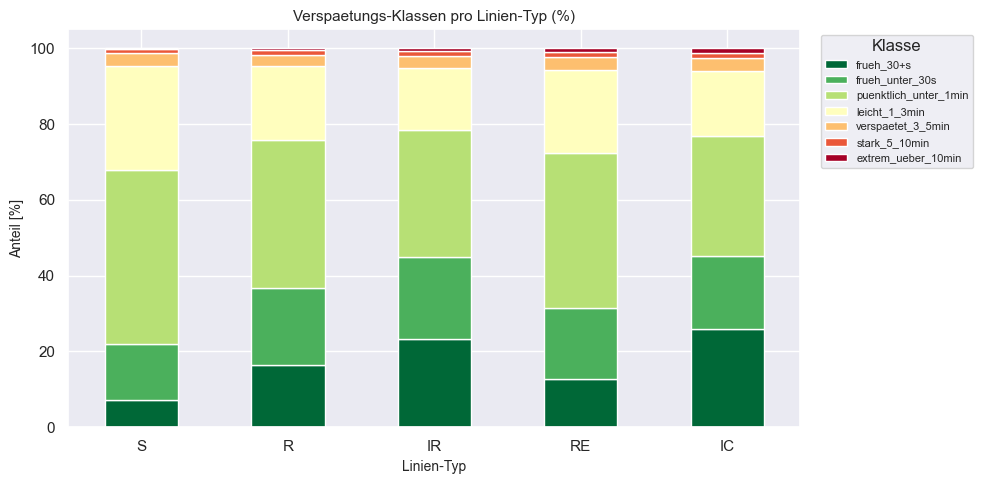

In [21]:
class_order = ["frueh_30+s", "frueh_unter_30s", "puenktlich_unter_1min",
               "leicht_1_3min", "verspaetet_3_5min", "stark_5_10min",
               "extrem_ueber_10min"]
# Nur Klassen, die tatsaechlich vorkommen
class_order = [c for c in class_order if c in df["delay_class"].unique()]

ct = pd.crosstab(df["verkehrsmittel_text"], df["delay_class"],
                 normalize="index") * 100
ct = ct.loc[df["verkehrsmittel_text"].value_counts().head(5).index, class_order]

plt.figure(figsize=(10, 5))
ct.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="RdYlGn_r")
plt.title("Verspaetungs-Klassen pro Linien-Typ (%)", fontsize=11)
plt.ylabel("Anteil [%]", fontsize=10)
plt.xlabel("Linien-Typ", fontsize=10)
plt.legend(title="Klasse", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Limitationen und Diskussion

- **Zeitraum begrenzt**: 48 Betriebstage (31. März – 19. Mai 2026).
  Saisonale Effekte (Winter, Bauarbeiten-Hochphase) nicht abgedeckt.
- **Nur SBB**: Andere Anbieter (BLS, SOB, RhB) fehlen — Ergebnisse
  gelten nur für SBB-Fernverkehr + S-Bahn.
- **Nicht-Unabhängigkeit der Beobachtungen** (wichtigste Einschränkung):
  Die 2.7 Mio Halte sind in Zügen, Bahnhöfen und Betriebstagen
  geschachtelt (Pseudoreplikation). Die effektive Stichprobengrösse ist
  weit kleiner als n, weshalb die Roh-p-Werte zu optimistisch sind. Wir
  adressieren das mit (a) dem Tagesmittel-Robustheitstest oben (Effekt
  überlebt n=48), (b) dem Fokus auf **Effektstärken** (Cohen's d ≈ 0.12,
  η², \|r\| < 0.04) statt p-Werten. Eine vollständige Lösung wären
  Mixed-Effects-Modelle mit Random Intercepts (über Kursrahmen hinaus).
- **Wetter-Distanz**: Bahnhof zu Wetterstation kann bis ~40 km sein
  (Berg-Stationen). Mikroklimatische Effekte (Wind im Tal) verloren.
- **Multiples Testen**: Bei k=4 Test-Familien wäre die Bonferroni-Schwelle
  α = 0.05/4 = 0.0125. **Alle Tests überstehen sie** (p ≈ 0), die
  Signifikanz ist also nicht ein Artefakt multiplen Testens — wohl aber
  der enormen Stichprobengrösse (siehe Effektstärken).
- **Heteroskedastizität**: Der Breusch-Pagan-Test ist signifikant; die
  OLS-Standardfehler sind dadurch leicht zu optimistisch (Punktschätzer
  bleiben gültig).
- **Kausalität ≠ Korrelation**: Die OLS-Regression zeigt assoziative,
  keine kausalen Zusammenhänge. Stürmische Wettertage gehen oft mit
  Streckenarbeiten einher (Confounder).


## Zusammenfassung Notebook 03

Alle vier Hypothesen-Tests mit p-Values dokumentiert + visualisiert.
Der Datensatz erlaubt klare Aussagen über Werktag-Effekte, Linientyp-
Unterschiede, Wetter-Korrelation und multivariate Erklärung.

**Nächste Schritte**:
- Streamlit-Webapp baut auf dieser DB + diesen Erkenntnissen auf
- LLM-Klassifikation reichert die Daten qualitativ an (in der App)


In [22]:
# System-Info (Reproduzierbarkeits-Footer)
import platform
from platform import python_version
from datetime import datetime

print("-----------------------------------")
print(os.name.upper())
print(platform.system(), "|", platform.release())
print("Datetime:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python Version:", python_version())
print("-----------------------------------")


-----------------------------------
NT
Windows | 11
Datetime: 2026-05-21 21:31:38
Python Version: 3.12.10
-----------------------------------
